# Exploratory Data Analysis of Online Food Delivery Ecosystem ft.Zomato.

## AIM

---


The aim of this project is to analyze restaurant performance and customer preference patterns in an online food delivery ecosystem using Python-based data analytics, in order to identify key factors influencing restaurant ratings, pricing strategies, popularity, and customer engagement.

## EDA Objectives

---



1. Analyze restaurant performance
2. Understand customer preferences
3. Study pricing patterns
4. Evaluate impact of online services
5. Identify potential market opportunities

# 1. DATA IMPORTING AND LOADING

---



In [ ]:
import pandas as pd
import numpy as np
from google.colab import files
uploaded = files.upload()

Saving zomato.csv to zomato.csv


In [ ]:
df = pd.read_csv("zomato.csv")

In [ ]:
print("Dataset loaded successfully")

Dataset loaded successfully


1.1 DATA OVERVIEW




In [ ]:
df.shape

(51717, 17)

In [ ]:
df.head()

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   url                          51717 non-null  object
 1   address                      51717 non-null  object
 2   name                         51717 non-null  object
 3   online_order                 51717 non-null  object
 4   book_table                   51717 non-null  object
 5   rate                         43942 non-null  object
 6   votes                        51717 non-null  int64 
 7   phone                        50509 non-null  object
 8   location                     51696 non-null  object
 9   rest_type                    51490 non-null  object
 10  dish_liked                   23639 non-null  object
 11  cuisines                     51672 non-null  object
 12  approx_cost(for two people)  51371 non-null  object
 13  reviews_list                 51

In [ ]:
df.describe()

,votes
count,51717.000000
mean,283.697527
std,803.838853
min,0.000000
25%,7.000000
50%,41.000000
75%,198.000000
max,16832.000000


# 2. DATA PRE-PROCESSING

---







2.1 DATA QUALITY CHECK

In [ ]:
df.isnull().sum()

,0
url,0
address,0
name,0
online_order,0
book_table,0
rate,7775
votes,0
phone,1208
location,21
rest_type,227


In [ ]:
df.duplicated().sum()

np.int64(0)

2.2 DATA CLEANING


In [ ]:
df = df.drop_duplicates()
df.columns = df.columns.str.strip()

In [ ]:
df['rate'] = df['rate'].str.replace('/5','')

In [ ]:
df['rate'] = pd.to_numeric(df['rate'],errors='coerce')

In [ ]:
df['approx_cost(for two people)'] = pd.to_numeric(
    df['approx_cost(for two people)'].str.replace(',',''),errors='coerce'
)

2.3 HANDLING MISSING COLUMNS

In [ ]:
df = df.dropna(subset=['rate','approx_cost(for two people)','location'])
df = df.drop(columns=['phone'])

2.4 DERIVED COLUMNS

In [ ]:
df['price_category'] = pd.cut(
    df['approx_cost(for two people)'],
    bins=[0,500,1000,2000,6000],
    labels=['Low','Medium','High','Luxury']
)

2.5 FILTERING

In [ ]:
high_rated = df[df['rate'] > 4]
high_rated.head()

,url,address,name,online_order,book_table,rate,votes,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city),price_category
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1,775,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800.0,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari,Medium
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1,787,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800.0,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari,Medium
7,https://www.zomato.com/bangalore/onesta-banash...,"2469, 3rd Floor, 24th Cross, Opposite BDA Comp...",Onesta,Yes,Yes,4.6,2556,Banashankari,"Casual Dining, Cafe","Farmhouse Pizza, Chocolate Banana, Virgin Moji...","Pizza, Cafe, Italian",600.0,"[('Rated 5.0', 'RATED\n I personally really l...",[],Cafes,Banashankari,Medium
9,https://www.zomato.com/bangalore/smacznego-ban...,"2470, 21 Main Road, 25th Cross, Banashankari, ...",Smacznego,Yes,No,4.2,504,Banashankari,Cafe,"Waffles, Pasta, Coleslaw Sandwich, Choco Waffl...","Cafe, Mexican, Italian, Momos, Beverages",550.0,"[('Rated 4.0', ""RATED\n Easy to locate\nVFM 3...",[],Cafes,Banashankari,Medium
10,https://www.zomato.com/bangalore/caf%C3%A9-dow...,"12,29 Near PES University Back Gate, D'Souza N...",CafÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂ© Down The A...,Yes,No,4.1,402,Banashankari,Cafe,"Waffles, Pasta, Crispy Chicken, Honey Chilli C...",Cafe,500.0,"[('Rated 4.0', 'RATED\n We ended up here on a...",[],Cafes,Banashankari,Low


2.6 AGGREGATION

In [ ]:
df.groupby('location')['rate'].mean()

,rate
location,
BTM,3.571659
Banashankari,3.649866
Banaswadi,3.492161
Bannerghatta Road,3.506260
Basavanagudi,3.671092
...,...
West Bangalore,3.366667
Whitefield,3.623209
Wilson Garden,3.536364


2.7 DATASET OVERVIEW

In [ ]:
df.shape
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 41418 entries, 0 to 51716
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   url                          41418 non-null  object  
 1   address                      41418 non-null  object  
 2   name                         41418 non-null  object  
 3   online_order                 41418 non-null  object  
 4   book_table                   41418 non-null  object  
 5   rate                         41418 non-null  float64 
 6   votes                        41418 non-null  int64   
 7   location                     41418 non-null  object  
 8   rest_type                    41271 non-null  object  
 9   dish_liked                   23327 non-null  object  
 10  cuisines                     41410 non-null  object  
 11  approx_cost(for two people)  41418 non-null  float64 
 12  reviews_list                 41418 non-null  object  
 13  menu_i

**INSIGHT**: The dataset contains 41418 valid restaurant records after cleaning and error handling (data pre-processing step).Key numerical variables have been successfully converted into appropriate data types for quantitative analysis.Also a new column "price_category" is created to categorize restaurant into pricing segments.

In [ ]:
df.to_csv("zomato_cleaned.csv",index=False)

# 3. STATISTICAL SUMMARY

---



In [ ]:
df.describe()

,rate,votes,approx_cost(for two people)
count,41418.000000,41418.000000,41418.000000
mean,3.700353,351.726013,603.268048
std,0.440637,882.697962,464.327857
min,1.800000,0.000000,40.000000
25%,3.400000,21.000000,300.000000
50%,3.700000,73.000000,500.000000
75%,4.000000,277.000000,700.000000
max,4.900000,16832.000000,6000.000000


**INSIGHT** : The dataset shows that restaurant ratings are relatively stable and concentrated around 3.5–4, indicating consistent but moderate quality across establishments. However, votes are highly skewed, suggesting that only a small number of restaurants receive significant customer attention. Pricing is centered around mid-range values (₹300–₹700), with a few premium outliers. Overall, the market is competitive with limited differentiation in ratings but strong inequality in popularity.

# 4. MISSING VALUE ANALYSIS

---



In [ ]:
df.isnull().sum()

,0
url,0
address,0
name,0
online_order,0
book_table,0
rate,0
votes,0
location,0
rest_type,147
dish_liked,18091


**INSIGHT** : The dataset has been cleaned in the data pre-processing phase by deleting duplicates,removing missing columns and fixing datatype.The dataset shows no misssing values in key variables such as rating,cost,location,and votes.Overall, the dataset requires minimal preprocessing and is well-suited for further analysis.

# 5. UNIVARIATE ANALYSIS

---



5.1 Analysis : Rating Distribution

    Objective - To understand how restaurant ratings are distributed.

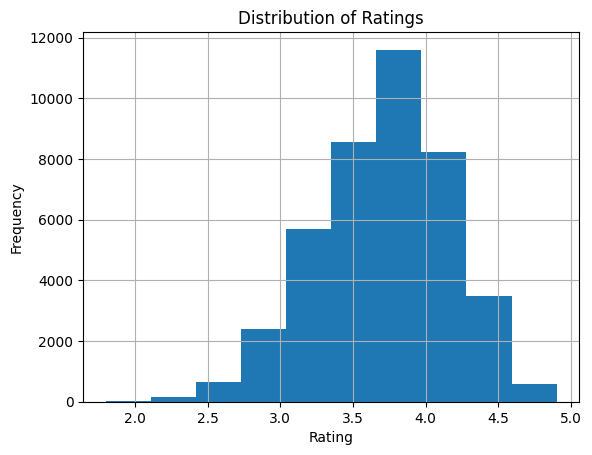

In [ ]:
import matplotlib.pyplot as plt

df['rate'].hist()
plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()

**INSIGHT**: The distribution of ratings is approximately normal, with most restaurants clustered between 3.3 and 4.2 and a peak around 3.7–4.0. This indicates that the majority of restaurants are moderately well-rated, with very few extreme low or high ratings. The narrow spread suggests a competitive market where most establishments perform similarly, making differentiation challenging.

5.2 Analysis : Price Category Distribution
    
    Objective : To understand the distribution of restaurants across price ranges

In [ ]:
df['price_category'].value_counts()

,count
price_category,
Low,24575
Medium,11708
High,4518
Luxury,617


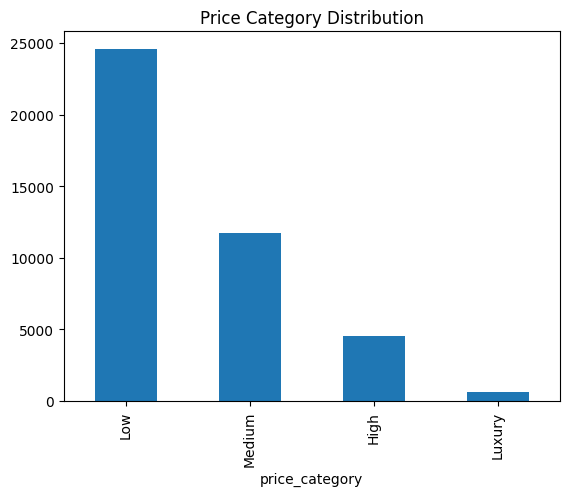

In [ ]:
df['price_category'].value_counts().plot(kind='bar')
plt.title("Price Category Distribution")
plt.show()

INSIGHT : The market follows a pyramid structure with a large base of low-cost restaurants,accounting for nearly 60% of the dataset, followed by medium - priced establishments at around and a very small luxury segment.High end and luxury restaurants are comparitively fewer, indicating that the market is largely driven by affordablity and food delivery ecosystem mainly centers to budgetfriendly customers.The distribution is highly imbalanced, with very limited representation of premium segments.

5.3 Analysis : Customer Preference Analysis

    Objective : To understand popular restaurant types.

In [ ]:
df['rest_type'].value_counts().head(10)

,count
rest_type,
Quick Bites,13885
Casual Dining,9616
Cafe,3369
Dessert Parlor,1850
Delivery,1671
"Takeaway, Delivery",1279
"Casual Dining, Bar",1092
Bakery,704
Beverage Shop,642


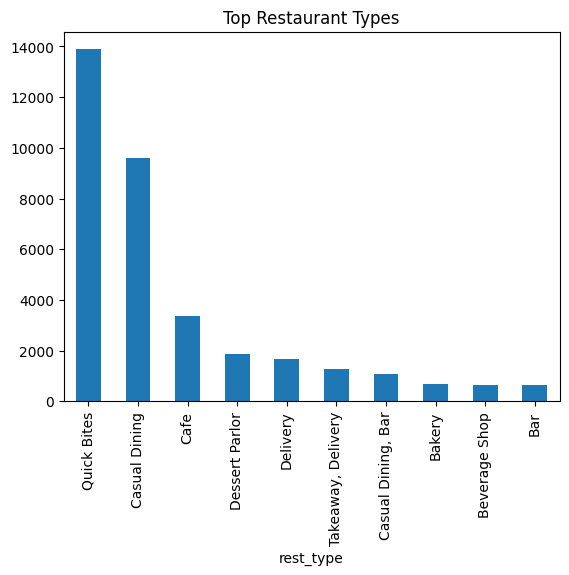

In [ ]:
df['rest_type'].value_counts().head(10).plot(kind="bar")
plt.title("Top Restaurant Types")
plt.show()

**INSIGHT** : The analysis of restaurant types shows that quick bite establishments dominate the market, indicating a strong customer preference for convenient and affordable dining options. Casual dining follows as the second most popular choice, reflecting demand for social and experiential dining. Other categories such as cafés, delivery outlets, and dessert parlors serve more niche purposes. Overall, customer behavior is primarily driven by convenience, cost-effectiveness, and occasional experiential dining.



# 6. BIVARIATE ANALYSIS

---



6.1 Analysis : Cost vs Rating

    Objective : To analyze whether higher_priced restaurants have better ratings.

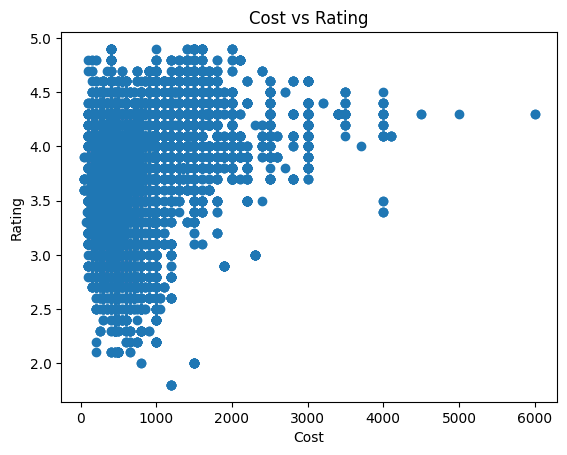

In [ ]:
plt.scatter(df['approx_cost(for two people)'], df['rate'])
plt.xlabel("Cost")
plt.ylabel("Rating")
plt.title("Cost vs Rating")
plt.show()

**INSIGHT** : The scatter plot shows a weak positive relationship between cost and ratings, indicating that higher-priced restaurants tend to have slightly better ratings. However, the wide dispersion of data points suggests that cost is not a strong predictor of customer satisfaction. Low-cost restaurants exhibit high variability in ratings, while higher-cost establishments tend to maintain more consistent quality. Overall, factors beyond price, such as service and ambience, play a significant role in determining ratings.

<Axes: xlabel='price_category', ylabel='rate'>

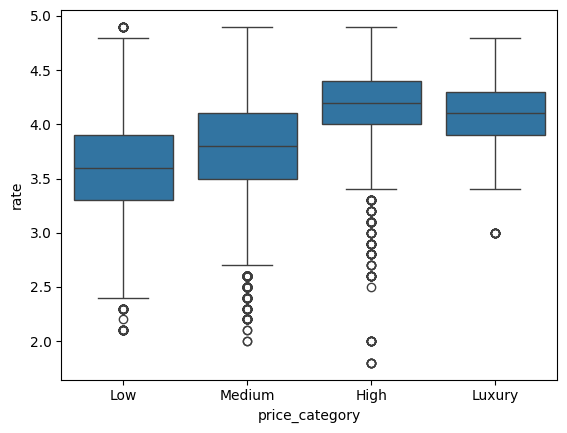

In [ ]:
sns.boxplot(x='price_category', y='rate', data=df)

**INSIGHT** : The boxplot shows that median ratings increase with price category, indicating that higher - priced restaurants generally offer better customer experiences.However,the overlap in rating distributions across categories suggests that price is not a definitive indicator of quality.Lower - priced restaurants exhibit greater variablity in ratings,while higher-priced ones are more consistent.Additionally,the similarity between high and luxury categories highlights dimnishing returns in customer satisfaction beyond a certain price point.


6.2 Analysis : Impact of Online Ordering

    Objective : To evaluate whether online ordering affects restaurant ratings.

In [ ]:
df.groupby('online_order')['rate'].mean()

,rate
online_order,
No,3.658071
Yes,3.722440


**INSIGHT**: The analysis shows that restaurants offering online ordering have slightly higher average ratings compared to those that do not. However, the difference is minimal, indicating that while convenience features like online ordering may enhance customer experience, they are not a major determinant of ratings. Other factors such as food quality, service, and ambience likely play a more significant role.

In [ ]:
df.groupby(['online_order','price_category'],observed=True)['rate'].mean()

online_order  price_category
No            Low               3.494803
              Medium            3.666620
              High              4.064079
              Luxury            4.123268
Yes           Low               3.622623
              Medium            3.799890
              High              4.204496
              Luxury            4.125926
Name: rate, dtype: float64

**INSIGHT** : The analysis shows that online ordering has a positive impact on restaurant ratings across all price categories, with the effect being more pronounced in low and medium-priced segments. This suggests that convenience plays a significant role in improving customer satisfaction for budget-conscious consumers. However, in the luxury segment, online ordering has minimal impact, indicating that customers in this category prioritize experience and ambience over convenience. Overall, the importance of online ordering varies across customer segments.

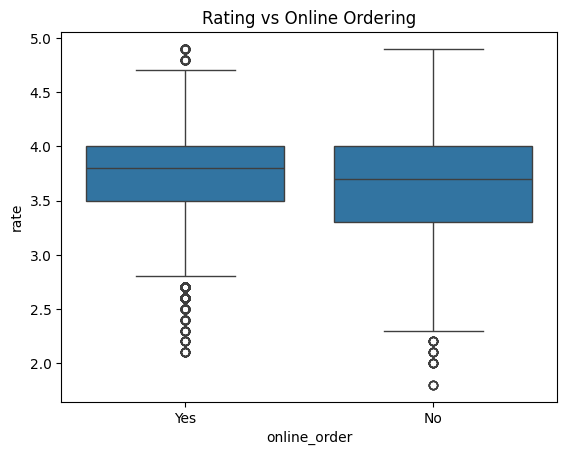

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='online_order', y='rate', data=df)
plt.title("Rating vs Online Ordering")
plt.show()

**INSIGHT** : The boxplot shows that restaurants offering online ordering have a slightly higher median rating and more consistent performance compared to those that do not. However, there is significant overlap between the two categories, indicating that online ordering is not a strong determinant of customer satisfaction. While it contributes to stability and convenience, other factors such as food quality and service play a more dominant role.Both categories have low-rating outliers.

6.3 Analysis : Votes vs Ratings

    Objective : To analyze relashionship between popularity and ratings

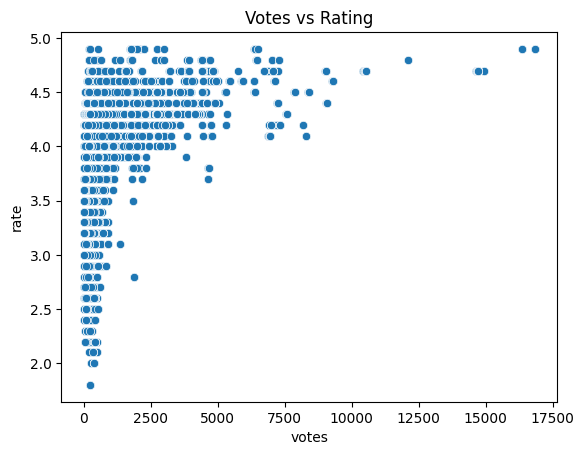

In [ ]:
sns.scatterplot(x='votes' , y='rate' , data=df)
plt.title("Votes vs Rating")
plt.show()

**INSIGHT**: The scatter plot shows a weak positive relationship between votes and ratings, indicating that more popular restaurants tend to have slightly higher ratings. However, the relationship is not strong, as many low-vote restaurants also exhibit high ratings. High-vote restaurants are generally more consistent and maintain ratings above 4.0, suggesting that sustained popularity is associated with reliable quality. Overall, while popularity and ratings are related, they are influenced by different underlying factors.

# 7. MULTIVARIATE ANALYSIS

---



7.1 Analysis : Location + Price + Rating

    Objective : To understand how location and pricing together affect ratings.

In [ ]:
df.groupby(['location','price_category'])['rate'].mean().head(10)

/tmp/ipykernel_1086/3859764660.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['location','price_category'])['rate'].mean().head(10)


location      price_category
BTM           Low               3.554067
              Medium            3.593598
              High              4.145313
              Luxury                 NaN
Banashankari  Low               3.594433
              Medium            3.750885
              High              3.986667
              Luxury                 NaN
Banaswadi     Low               3.498324
              Medium            3.460825
Name: rate, dtype: float64

**INSIGHT** : The analysis shows that the positive relationship between price category and ratings is consistent across different locations, with higher-priced restaurants receiving better ratings in all areas. However, there are slight variations in ratings within the same price category across locations, indicating that local factors such as customer expectations and competition influence customer satisfaction. Additionally, the absence of luxury restaurants in some locations suggests that demand for premium dining is location-dependent.

# 8. GROUPBY ANALYSIS

---



8.1 Analysis : Top Performing Locations

    Objective : To identify locations with the highest average ratings.

In [ ]:
df.groupby(['location','price_category'],observed=True)['rate'].mean().head(10)

location           price_category
BTM                Low               3.554067
                   Medium            3.593598
                   High              4.145313
Banashankari       Low               3.594433
                   Medium            3.750885
                   High              3.986667
Banaswadi          Low               3.498324
                   Medium            3.460825
                   High              3.541176
Bannerghatta Road  Low               3.450363
Name: rate, dtype: float64

In [ ]:
df.groupby('location')['rate'].mean().sort_values(ascending=False).head(10)

,rate
location,
Lavelle Road,4.141788
Koramangala 3rd Block,4.020419
St. Marks Road,4.017201
Koramangala 5th Block,4.006661
Church Street,3.992125
Sankey Road,3.965385
Koramangala 4th Block,3.918668
Cunningham Road,3.901053
Residency Road,3.864570


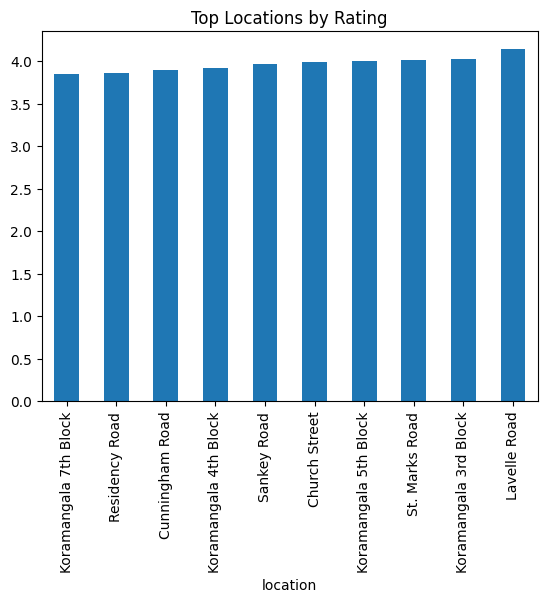

In [ ]:
df.groupby('location')['rate'].mean().sort_values().tail(10).plot(kind='bar')
plt.title("Top Locations by Rating")
plt.show()

**INSIGHT**: The analysis shows that in terms of price category,BTM emerges as a top-performing location, particularly in the high-price segment, indicating strong demand for premium dining experiences. Banashankari demonstrates consistent performance across all price categories, making it a stable market. In contrast, Banaswadi underperforms across segments, suggesting relatively lower customer satisfaction. Overall, while price category remains the primary driver of ratings, location plays a secondary role in shaping customer perception and differentiating performance across areas.

In terms of rating, the analysis identifies Lavelle Road as the top-performing location with the highest average ratings, followed by several areas in Koramangala, which emerges as a major restaurant hub with consistently strong performance. Central urban locations such as Church Street and St. Marks Road also show high ratings, indicating that premium and high-footfall areas tend to host better-performing restaurants. However, the variation in ratings across locations is relatively small, suggesting an overall competitive and consistently high-quality market.

Overall, restaurant performance is driven by a combination of pricing, location, and customer experience.

8.2 Analysis : Pricing Strategy Effectiveness

    Objective : To evaluate how pricing categories influence ratings.

In [ ]:
df.groupby('price_category', observed=True)['rate'].mean()

,rate
price_category,
Low,3.582490
Medium,3.759481
High,4.130434
Luxury,4.123501


**INSIGHT**:  The analysis shows a positive relationship between price category and restaurant ratings, with higher-priced restaurants receiving better average ratings. However, the difference between high and luxury categories is minimal, indicating diminishing returns in customer satisfaction beyond a certain price point. This suggests that while price is associated with perceived quality, extremely high pricing does not significantly enhance customer experience.

8.3 Analysis : Pricing vs Rating
   
    Objective : To evaluate effectiveness of pricing strategy.

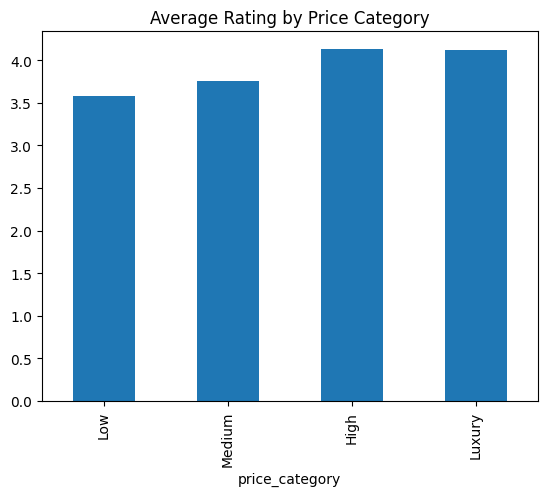

In [ ]:
df.groupby('price_category', observed=True)['rate'].mean().plot(kind='bar')
plt.title("Average Rating by Price Category")
plt.show()

**INSIGHT** : The analysis shows a clear positive relationship between price category and customer ratings, with higher-priced restaurants generally receiving better ratings. The most significant improvement is observed when moving from medium to high price categories, indicating that premium positioning enhances customer satisfaction. However, the luxury segment does not show further improvement over the high category, suggesting diminishing returns in perceived value. Overall, the high-price category emerges as the optimal segment for maximizing customer satisfaction.

In [ ]:
df.groupby('rest_type')['rate'].mean().sort_values(ascending=False)

,rate
rest_type,
"Pub, Cafe",4.657500
"Bar, Pub",4.600000
Microbrewery,4.478571
"Pub, Microbrewery",4.452632
"Microbrewery, Bar",4.446154
...,...
Bhojanalya,3.266667
"Food Court, Casual Dining",3.240000
"Bakery, Beverage Shop",3.200000


**INSIGHT** : The analysis shows that experience-oriented restaurant types such as pubs, bars, and microbreweries receive the highest ratings, indicating that ambience and social experience play a key role in customer satisfaction. In contrast, functional dining options like bakeries, food courts, and kiosks have lower ratings, as they focus more on convenience than experience. This highlights a key distinction between customer usage and satisfaction — while quick-service restaurants dominate in volume, premium experience-based venues achieve higher ratings.

Customers frequently choose convinience based options like quick bites,but they rate experience driven places like pubs and microbrewerries significantly higher.

# 9. PIVOT TABLE ANALYSIS

---



9.1 Analysis : Location vs Price Category

    Objective : To compare ratings across different locations and price categories.

In [ ]:
pd.pivot_table(
    df,
    values='rate',
    index='location',
    columns='price_category',
    aggfunc='mean',observed=True
)

price_category,Low,Medium,High,Luxury
location,,,,
BTM,3.554067,3.593598,4.145313,NaN
Banashankari,3.594433,3.750885,3.986667,NaN
Banaswadi,3.498324,3.460825,3.541176,NaN
Bannerghatta Road,3.450363,3.596875,4.075000,NaN
Basavanagudi,3.654605,3.758140,2.700000,3.700
...,...,...,...,...
West Bangalore,3.366667,NaN,NaN,NaN
Whitefield,3.471149,3.676510,4.014043,4.288
Wilson Garden,3.506000,3.659459,NaN,NaN


**INSIGHT** : The analysis shows that the positive relationship between price category and ratings is consistent across most locations, with higher-priced restaurants generally receiving better ratings. However, the effectiveness of premium pricing varies by location. Areas like Whitefield show strong performance in high and luxury segments, indicating suitability for premium dining, while locations like Banaswadi underperform even in higher price categories. The presence of missing values for premium categories in several locations suggests that demand for high-end dining is location-specific. Overall, pricing strategy must be aligned with location characteristics to maximize performance.

Premium pricing works only where the location supports it.

# 10. CORRELATION ANALYSIS

---



10.1 Analysis : Relashionship Between Variables

    Objective : To measure relashionships between ratings, votes and cost.

In [ ]:
df[['rate','votes','approx_cost(for two people)']].corr()

,rate,votes,approx_cost(for two people)
rate,1.000000,0.434764,0.385183
votes,0.434764,1.000000,0.366700
approx_cost(for two people),0.385183,0.366700,1.000000


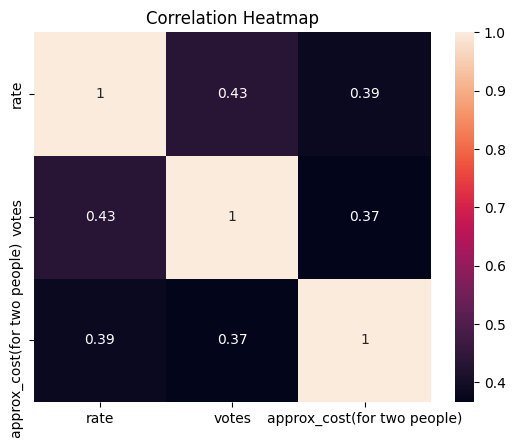

In [ ]:
sns.heatmap(df[['rate','votes','approx_cost(for two people)']].corr(),annot=True)
plt.title("Correlation Heatmap")
plt.show()

**INSIGHT** : The correlation analysis reveals moderate positive relationships between ratings, votes, and cost, indicating that higher-rated restaurants tend to be more popular and slightly more expensive. However, the correlations are not strong, suggesting that no single factor dominates customer satisfaction or popularity. Instead, restaurant success is influenced by a combination of factors including pricing, quality, visibility, and overall experience.

# 11. OUTLIER DETECTION

---



11.1 Analysis : Cost Outliers

    Objective : To identify unusually high or low pricing.

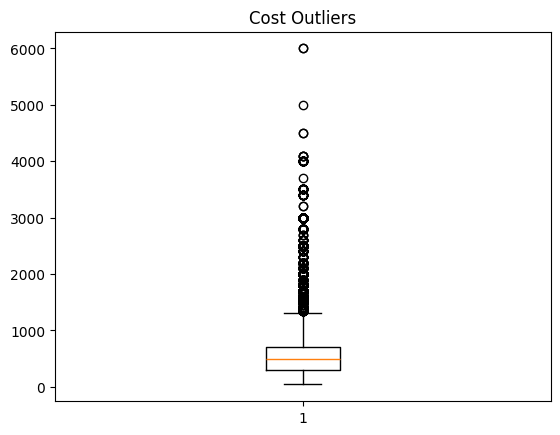

In [ ]:
plt.boxplot(df['approx_cost(for two people)'])
plt.title("Cost Outliers")
plt.show()

**INSIGHT** : The boxplot reveals that the majority of restaurants fall within the mid-range cost segment (₹300–₹700), while a significant number of high-cost outliers extend up to ₹6000. This indicates a highly right-skewed distribution, with a small but distinct luxury segment. The presence of extreme values suggests that while most of the market is driven by affordability, a niche segment caters to premium customers. These outliers can influence statistical measures and should be handled carefully during analysis.

The market is mass-driven ,with a small but powerful luxury tail.

# 12. INSIGHT GENERATION AND REPORT
---



1. Market is Dominated by Affordable Dining

    * Majority of restaurants fall in: Low (60%) and Medium (28%) price categories.
    * Cost distribution heavily concentrated around ₹300–₹700.
    * The food market is mass-driven,focused on affordability and frequent consumption.

2. Ratings Are Stable but Competitive
    * Most ratings lie between 3.5 – 4.2
    * Very few extreme ratings
    * The market is highly competitive, with most restaurants offering similar quality levels.

3. Price Positively Influences Ratings (But With Limits)
    * Ratings increase from:
   Low → Medium → High
    * Luxury ≈ High (no major improvement)
    * Pricing improves perception, but only up to a point (premium tier)

4. Location Shapes Performance, Not Quality Baseline
    * Premium locations:
Lavelle Road, Koramangala, Church Street
    * Some areas underperform even at high price.
    * Price sets quality, but location determines success potential

5. Customer Behavior: Convenience vs Experience
    * Most Used:
Quick Bites, Delivery
    * Highest Rated:
Pubs, Bars, Microbreweries
    * What people use most is not what they rate highest.
    * Convenience drives usage, experience drives satisfaction.

6. Popularity vs Quality
    * Votes (popularity) moderately correlated with ratings (~0.43)
    * High-vote restaurants usually have consistent good ratings.
    * Popularity reflects consistency over time, not just quality

7. Online Ordering Has Minor Impact
    * Slightly higher ratings for online-order-enabled restaurants
    * Convenience features enhance experience slightly, but are not decisive

8. No Strong Single Factor Drives Success
    * Correlations are moderate (0.35–0.45)
    * Restaurant success depends on a combination of factors, not one variable

9. Presence of Strong Outliers (Luxury Segment)
    * Cost goes up to ₹6000
    * Small but clear premium segment
    * Market has a long luxury tail, but core demand is budget-focused

10. Market Segmentation Model
    * Budget Segment:
High demand
Lower ratings
Convenience-driven
    * Mid Segment:
Balanced demand & quality
    * Premium Segment:
Lower demand
Highest ratings
Experience-driven

###  12.1. KEY FINDINGS

---



*   The ecosystem is dominated by low and mid-priced restaurants, reflecting strong customer preference for affordability.

*  Most restaurants fall within the ₹300–₹700 range, indicating a mass-market consumption pattern.

*  Ratings are concentrated between 3.5–4.2, showing a competitive and consistent performance landscape.

*   Higher-priced restaurants receive better ratings, indicating a positive price–quality perception.

*   Higher pricing improves ratings, but only up to the premium tier, after which returns diminish.

*   Customers prefer Quick Bites and Delivery, highlighting convenience-driven behavior.

*  Experience-driven restaurants (pubs, cafés, microbreweries) achieve the highest ratings, emphasizing the role of ambience.

*   Popularity (votes) is linked to consistent quality, not just high ratings alone.

*   Online ordering has only a minor impact on ratings, acting as a supporting factor.

*   Restaurant performance is driven by a combination of pricing, experience, location, and consistency, not a single factor.









## 12.2. SUMMARY

---

TThe exploratory data analysis of the Zomato-based online food delivery ecosystem reveals that restaurant performance and customer preferences are primarily driven by affordability, convenience, and experience. The market is dominated by low to mid-priced restaurants, indicating strong demand for budget-friendly options. While higher-priced restaurants tend to receive better ratings, the improvement stabilizes beyond the premium segment, showing diminishing returns for luxury pricing. Customer behavior reflects a dual pattern where convenience-driven options like quick bites are most used, but experience-oriented restaurants achieve higher satisfaction. Additionally, factors such as location, customer engagement (votes), and service consistency play a significant role, highlighting that restaurant success is influenced by multiple interconnected variables rather than a single factor.

# 13. BUSINESS INSIGHTS AND RECOMMENDATIONS

---



*   Launch a mid-to-high priced casual dining or café — balance of demand + quality
*   Location Strategy:Open in high-performing clusters with strong competition.
*   Pricing Strategy :Position in “High” category, not Luxury.Align pricing strategy with location demand and customer expectations.
*   Operations Strategy :Focus on consistent quality → more votes
*   Restaurant Type Strategy :Focus on casual dining or café formats that combine convenience with experience.
*   Enable online ordering and delivery to enhance convenience and reach.
*   Prioritize consistency in quality to drive higher votes and long-term popularity.
*   Design a concept that merges affordability, ambience, and accessibility.


*   The best strategy is to offer a premium experience at accessible pricing in a high-demand location.



# 14. OBJECTIVE-WISE VALIDATION

---

*   Analyze Restaurant Performance -
Identified that higher-priced and experience-driven restaurants achieve better ratings and consistency.
*   Understand Customer Preferences -
Found that customers prefer Quick Bites for convenience but rate experience-driven places (pubs/cafés) higher.
*   Study Pricing Patterns -
Established a positive price–rating relationship with diminishing returns beyond the premium segment.
*   Evaluate Impact of Online Services -
Determined that online ordering slightly improves ratings but has a minimal overall impact.
*   Identify Potential Market Opportunities -
Recommended targeting mid-to-high price segment in high-performing locations with experience-driven concepts.
